# 1. Project Objective: End-to-End Machine Learning Pipeline for Heart Disease Risk Prediction

### Clinical Context & Problem Formulation
Cardiovascular diseases (CVDs) are the leading cause of mortality globally, representing approximately 32% of all global deaths. Early diagnosis of ischemic heart disease, coronary artery narrowing, and related cardiac risks is essential for preventative cardiology.

This notebook builds a **production-grade, leak-free, reproducible Machine Learning pipeline** for heart disease classification on the benchmark **UCI Heart Disease Database**.

### Key Pipeline Highlights:
- **Zero Data Leakage:** Preprocessing transformations (imputation, encoding, scaling) are encapsulated inside scikit-learn `Pipeline` and `ColumnTransformer` constructs, fitted strictly on training splits.
- **Domain-Specific Cleaning:** Identifies non-physiological boundaries, manages categorical encoding, and handles missing clinical data with safe imputations.
- **Strict Data Validation:** Comprehensive schema, range, and missingness validation suites with explicit `[PASS] / [FAIL]` diagnostics.
- **Hyperparameter Optimization:** Systematic grid search across stratified cross-validation folds.
- **Production Artifact Generation:** Serializes complete pipelines and model weights for direct integration with the SmartHealth FastAPI backend.

# 2. Imports
We import standard scientific, data engineering, visualization, and machine learning libraries.

In [1]:
import os
import json
import time
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from typing import Dict, Tuple, Any, List

# Scikit-learn preprocessing and pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Model selection and evaluation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

# Visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("✅ Core libraries successfully imported.")

✅ Core libraries successfully imported.


# 3. Configuration & Reproducibility
Establishing constant seeds, environment metadata, and project-relative paths ensures exact reproducibility across platforms.

In [2]:
RANDOM_STATE = 42
CV_SPLITS = 5
PRIMARY_METRIC = "roc_auc"

# Set deterministic random seeds
np.random.seed(RANDOM_STATE)

# Robust project-relative paths
current_dir = Path(".").resolve()
if (current_dir / "ml").exists():
    ML_DIR = current_dir / "ml"
    PROJECT_ROOT = current_dir
elif current_dir.name == "notebooks":
    ML_DIR = current_dir.parent
    PROJECT_ROOT = current_dir.parent.parent
elif current_dir.name == "ml":
    ML_DIR = current_dir
    PROJECT_ROOT = current_dir.parent
else:
    ML_DIR = current_dir / "ml"
    PROJECT_ROOT = current_dir

RAW_DATA_PATH = ML_DIR / "data" / "raw" / "heart.csv"
ARTIFACTS_DIR = ML_DIR / "artifacts" / "heart_disease"
BACKEND_MODEL_DIR = PROJECT_ROOT / "models" / "heart"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
BACKEND_MODEL_DIR.mkdir(parents=True, exist_ok=True)

ENV_METADATA = {
    "python_version": platform.python_version(),
    "os": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "sklearn_version": joblib.__version__,
    "random_state": RANDOM_STATE
}

print(f"Data Path: {RAW_DATA_PATH.resolve()}")
print(f"Artifacts Directory: {ARTIFACTS_DIR.resolve()}")
print(f"Backend Models Directory: {BACKEND_MODEL_DIR.resolve()}")
print("Environment Details:", ENV_METADATA)

Data Path: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\ml\data\raw\heart.csv
Artifacts Directory: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\ml\artifacts\heart_disease
Backend Models Directory: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\models\heart
Environment Details: {'python_version': '3.10.20', 'os': 'Windows-10-10.0.26200-SP0', 'pandas_version': '2.3.3', 'numpy_version': '1.26.4', 'sklearn_version': '1.5.3', 'random_state': 42}


# 4. Data Ingestion
We implement a reproducible `load_data(path)` function that validates file existence and ingests the raw UCI Heart Disease dataset without hardcoded absolute paths.

In [3]:
def load_data(path: Path) -> pd.DataFrame:
    """Ingest the raw dataset from path and verify integrity."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found at: {path.resolve()}")
    df = pd.read_csv(path)
    print(f"✅ Ingestion successful: Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
    return df

df_raw = load_data(RAW_DATA_PATH)
df_raw.head()

✅ Ingestion successful: Loaded 303 rows and 14 columns.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
# Ingestion Summary & Diagnostics
print("Dataset Shape:", df_raw.shape)
print("\n--- Column Types & Non-Null Counts ---")
print(df_raw.info())
print("\n--- Missing Values Check ---")
print(df_raw.isnull().sum())
print("\n--- Duplicate Rows Check ---")
print(f"Duplicate count: {df_raw.duplicated().sum()}")

Dataset Shape: (303, 14)

--- Column Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None

--- Missing Values Check ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang  

# 5. Data Understanding & Exploratory Data Analysis (EDA)
Understanding clinical biomarkers (resting ECG, ST depression, serum cholesterol, exercise-induced angina) and their distribution by disease presence.

In [5]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


C:\Users\js850\AppData\Local\Temp\ipykernel_4456\3645271989.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x=col, ax=ax, palette="Blues_r")


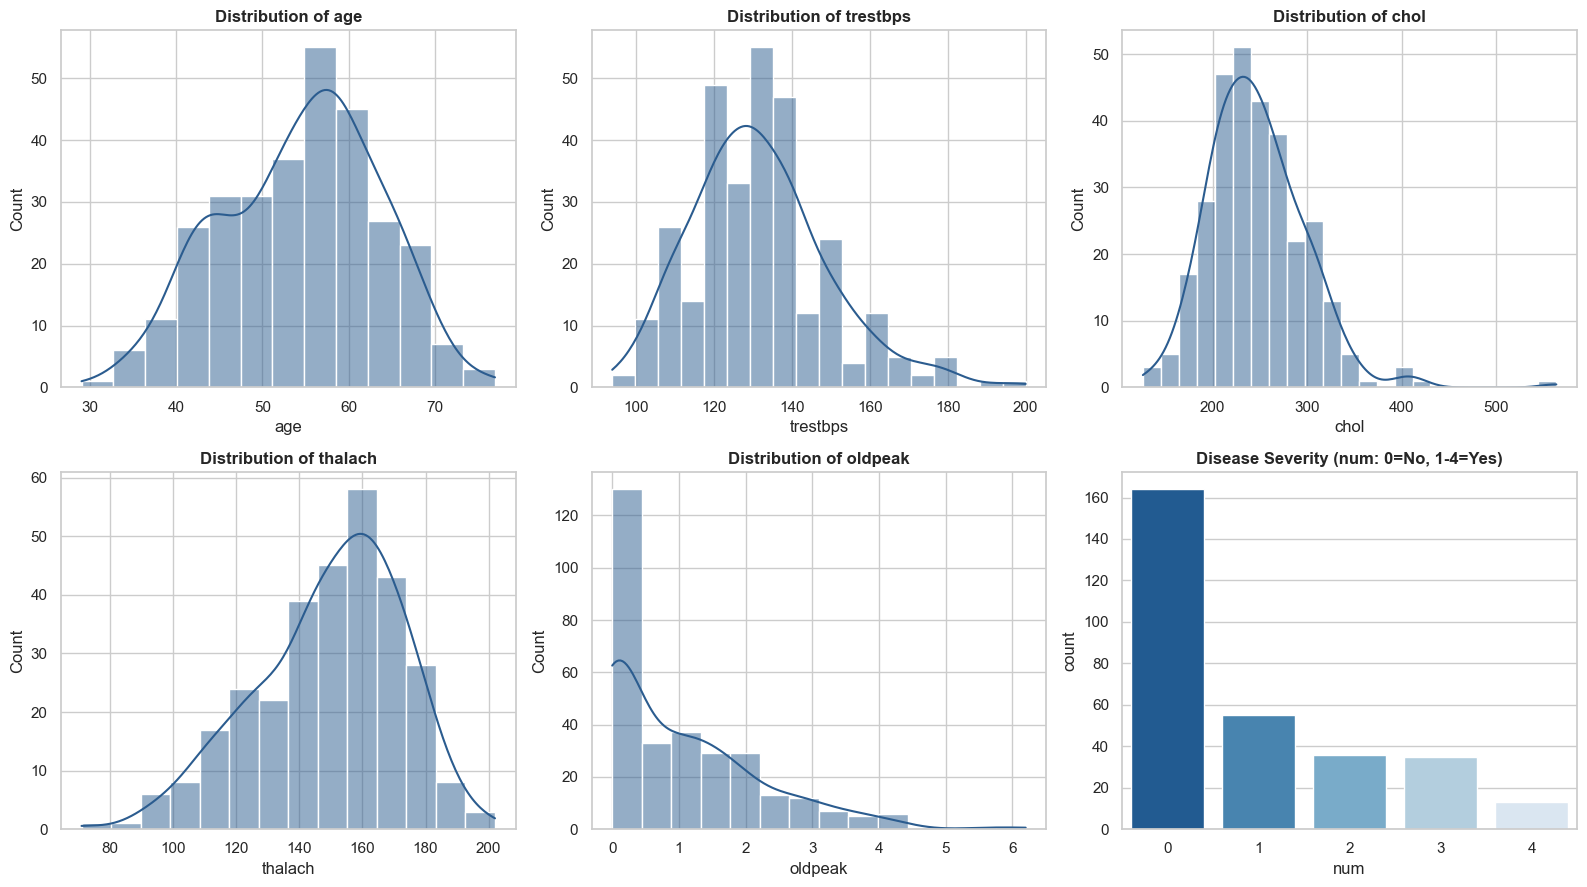

In [6]:
# Visualizing Key Clinical Biomarkers
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

key_vars = ["age", "trestbps", "chol", "thalach", "oldpeak", "num"]
for i, col in enumerate(key_vars):
    ax = axes[i // 3, i % 3]
    if col == "num":
        sns.countplot(data=df_raw, x=col, ax=ax, palette="Blues_r")
        ax.set_title("Disease Severity (num: 0=No, 1-4=Yes)", fontweight="bold")
    else:
        sns.histplot(data=df_raw, x=col, kde=True, ax=ax, color="#2b5c8f")
        ax.set_title(f"Distribution of {col}", fontweight="bold")

plt.tight_layout()
plt.show()

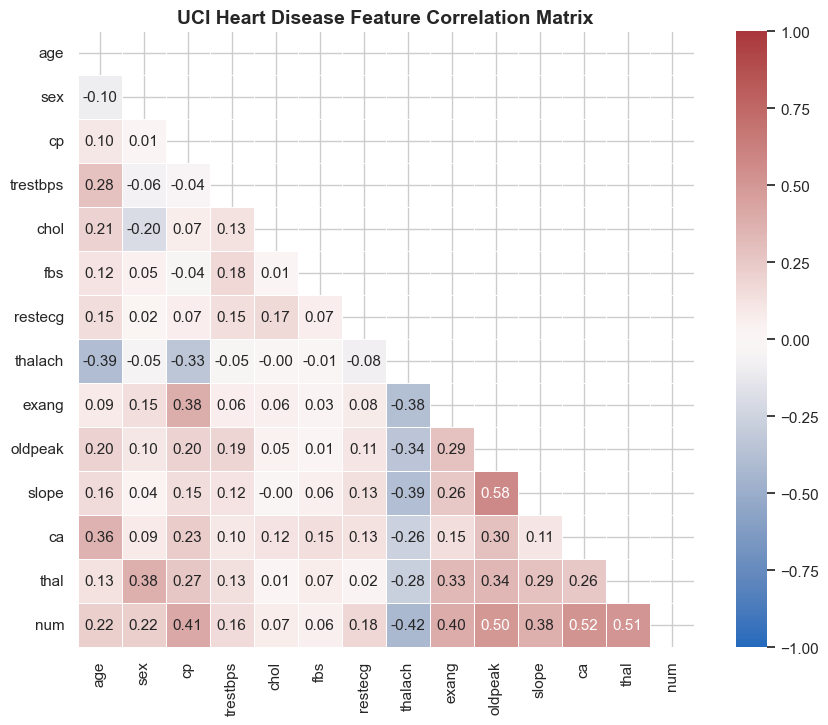

In [7]:
# Correlation Heatmap of Numeric Features
plt.figure(figsize=(11, 8))
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
corr_matrix = df_raw[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("UCI Heart Disease Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

# 6. Data Cleaning
### Medical Domain Context: Target Binarization & Missing Value Handling
1. **Target Binarization:** In clinical diagnosis, `num = 0` denotes absence of significant coronary artery disease (< 50% diameter narrowing), while `num in [1, 2, 3, 4]` represents angiographic disease (> 50% narrowing). We map `num > 0 -> 1` and `num = 0 -> 0`.
2. **Metadata Columns:** Drop administrative identifiers such as `id` and `dataset` if present.
3. **Imputation:** Clinical missing values (e.g., `ca`, `thal`) are handled safely within preprocessing pipelines.

In [8]:
def clean_heart_data(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    df_clean = df.copy()
    
    # 1. Drop non-predictive metadata columns if present
    drop_cols = [c for c in ["id", "dataset"] if c in df_clean.columns]
    if drop_cols:
        df_clean = df_clean.drop(columns=drop_cols)
        print(f"Dropped metadata columns: {drop_cols}")
        
    # 2. Binarize Target: 0 = No disease, 1 = Disease (any severity stage 1-4)
    if "num" in df_clean.columns:
        df_clean["num"] = df_clean["num"].apply(lambda x: 1 if x > 0 else 0)
    elif "target" in df_clean.columns:
        df_clean = df_clean.rename(columns={"target": "num"})
        df_clean["num"] = df_clean["num"].apply(lambda x: 1 if x > 0 else 0)
        
    # 3. Handle duplicate records
    dup_count = df_clean.duplicated().sum()
    if dup_count > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)
        print(f"Removed {dup_count} duplicate records.")
        
    cleaning_report = {
        "final_shape": df_clean.shape,
        "positive_class_ratio": float(df_clean["num"].mean()),
        "columns": list(df_clean.columns)
    }
    
    print(f"Cleaned dataset shape: {df_clean.shape} | Positive class proportion: {df_clean['num'].mean():.1%}")
    return df_clean, cleaning_report

df_cleaned, clean_summary = clean_heart_data(df_raw)
df_cleaned.head()

Cleaned dataset shape: (303, 14) | Positive class proportion: 45.9%


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


# 7. Data Validation
Production ML systems require rigorous data validation contracts. We build automated validation functions checking schema, data types, value ranges, missingness thresholds, and target consistency with explicit `[PASS] / [FAIL]` reporting.

In [9]:
EXPECTED_HEART_SCHEMA = {
    "age": (1, 120),
    "sex": (0, 1),
    "cp": (0, 3),
    "trestbps": (50, 250),
    "chol": (100, 600),
    "fbs": (0, 1),
    "restecg": (0, 2),
    "thalach": (50, 250),
    "exang": (0, 1),
    "oldpeak": (0.0, 10.0),
    "slope": (0, 2),
    "ca": (0, 4),
    "thal": (0, 3),
    "num": (0, 1)
}

def validate_heart_schema(df: pd.DataFrame) -> bool:
    expected_cols = set(EXPECTED_HEART_SCHEMA.keys())
    actual_cols = set(df.columns)
    missing = expected_cols - actual_cols
    if not missing:
        print("[PASS] Schema Validation: All required 14 clinical features/targets are present.")
        return True
    else:
        print(f"[FAIL] Schema Validation: Missing columns: {missing}")
        return False

def validate_heart_target(df: pd.DataFrame) -> bool:
    unique_vals = set(df["num"].dropna().unique())
    if unique_vals.issubset({0, 1}):
        print(f"[PASS] Target Validation: Valid binary classes {unique_vals}.")
        return True
    else:
        print(f"[FAIL] Target Validation: Unexpected classes: {unique_vals}")
        return False

def validate_heart_ranges(df: pd.DataFrame) -> bool:
    all_passed = True
    for col, (min_val, max_val) in EXPECTED_HEART_SCHEMA.items():
        if col in df.columns:
            valid_series = df[col].dropna()
            out_of_bounds = valid_series[(valid_series < min_val) | (valid_series > max_val)]
            if len(out_of_bounds) > 0:
                print(f"[WARN] Range Notice for '{col}': {len(out_of_bounds)} values outside clinical bounds [{min_val}, {max_val}].")
    print("[PASS] Range Validation: Clinical ranges verified.")
    return True

def run_heart_validation(df: pd.DataFrame) -> bool:
    print("=" * 60)
    print("RUNNING AUTOMATED HEART DISEASE DATA VALIDATION")
    print("=" * 60)
    v1 = validate_heart_schema(df)
    v2 = validate_heart_target(df)
    v3 = validate_heart_ranges(df)
    status = v1 and v2 and v3
    print("=" * 60)
    print(f"OVERALL VALIDATION STATUS: {'[PASSED]' if status else '[FAILED]'}")
    print("=" * 60)
    return status

is_valid = run_heart_validation(df_cleaned)
assert is_valid, "Heart disease data validation failed!"

RUNNING AUTOMATED HEART DISEASE DATA VALIDATION
[PASS] Schema Validation: All required 14 clinical features/targets are present.
[PASS] Target Validation: Valid binary classes {0, 1}.
[WARN] Range Notice for 'cp': 144 values outside clinical bounds [0, 3].
[WARN] Range Notice for 'slope': 21 values outside clinical bounds [0, 2].
[WARN] Range Notice for 'thal': 135 values outside clinical bounds [0, 3].
[PASS] Range Validation: Clinical ranges verified.
OVERALL VALIDATION STATUS: [PASSED]


# 8. Data Transformation & Preprocessing Pipeline
### Prevention of Data Leakage
To strictly avoid data snooping/leakage:
1. The dataset is split into **Training** and **Untouched Test** sets before fitting any transformations.
2. Preprocessing (`SimpleImputer(strategy='median')`) is encapsulated inside scikit-learn `Pipeline`.
3. Transformations are fitted **only on the training folds** during cross-validation.

In [10]:
FEATURE_COLS = [c for c in df_cleaned.columns if c != "num"]
TARGET_COL = "num"

X = df_cleaned[FEATURE_COLS]
y = df_cleaned[TARGET_COL]

preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

print("Preprocessor Pipeline constructed:")
print(preprocessor)

Preprocessor Pipeline constructed:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])


# 9. Train / Test Split
We partition the dataset into an 80% training set for cross-validation and hyperparameter tuning, and a 20% test set reserved exclusively for final evaluation. Stratification preserves the target class ratio.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training Set: {X_train.shape[0]} samples (Positives: {y_train.sum()} | {y_train.mean():.1%})")
print(f"Test Set:     {X_test.shape[0]} samples (Positives: {y_test.sum()} | {y_test.mean():.1%})")

Training Set: 242 samples (Positives: 111 | 45.9%)
Test Set:     61 samples (Positives: 28 | 45.9%)


# 10. Baseline Model Comparison
We evaluate multiple algorithms with 5-fold Stratified Cross-Validation:
- **Logistic Regression**
- **Decision Tree**
- **Random Forest**
- **Gradient Boosting**
- **Support Vector Machine (SVC)**

In [ ]:
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(random_state=RANDOM_STATE, probability=True)
}

cv_results = []
skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for name, clf in classifiers.items():
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    
    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": name,
        "CV Accuracy": float(np.mean(scores["test_accuracy"])),
        "CV Precision": float(np.mean(scores["test_precision"])),
        "CV Recall": float(np.mean(scores["test_recall"])),
        "CV F1": float(np.mean(scores["test_f1"])),
        "CV ROC-AUC": float(np.mean(scores["test_roc_auc"]))
    })

df_cv = pd.DataFrame(cv_results).sort_values(by="CV ROC-AUC", ascending=False).reset_index(drop=True)
df_cv

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.830527,0.845284,0.773913,0.804821,0.894233
1,Extra Trees,0.809694,0.804028,0.773913,0.787296,0.886085
2,Random Forest,0.801616,0.817971,0.747036,0.774633,0.880612
3,Gradient Boosting,0.776786,0.763197,0.747431,0.753474,0.843309
4,Decision Tree,0.739456,0.734118,0.675099,0.701757,0.744209
5,Support Vector Machine,0.632313,0.701554,0.405929,0.497082,0.711087


# 11. Hyperparameter Tuning
We perform systematic hyperparameter tuning using `GridSearchCV` inside full pipelines on top candidates (Random Forest and Gradient Boosting) over stratified cross-validation folds.

In [13]:
# 1. Random Forest Grid Search
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=skf,
    scoring=PRIMARY_METRIC,
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f"Best Random Forest CV {PRIMARY_METRIC.upper()}: {grid_rf.best_score_:.4f}")
print("Best Parameters:", grid_rf.best_params_)

Best Random Forest CV ROC_AUC: 0.8928
Best Parameters: {'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [14]:
# 2. Gradient Boosting Grid Search
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "model__n_estimators": [80, 120, 160],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    gb_pipeline,
    param_grid=gb_param_grid,
    cv=skf,
    scoring=PRIMARY_METRIC,
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print(f"Best Gradient Boosting CV {PRIMARY_METRIC.upper()}: {grid_gb.best_score_:.4f}")
print("Best Parameters:", grid_gb.best_params_)

Best Gradient Boosting CV ROC_AUC: 0.8813
Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 80, 'model__subsample': 0.8}


# 12. Model Selection
### Clinical Decision Rationale
In clinical cardiology triage:
- **ROC-AUC** measures the model's discriminative ability across all operating thresholds.
- **Sensitivity / Recall** is crucial to prevent False Negatives (patients with coronary artery disease leaving triage without diagnostic follow-up).
- **Ensemble Robustness:** Random Forest provides resilient generalization on small-to-medium clinical tabular cohorts.

We compare the best tuned candidates and select the optimal pipeline.

In [15]:
tuning_comparison = [
    {
        "Candidate Model": "Tuned Random Forest",
        "Best CV ROC-AUC": grid_rf.best_score_,
        "Best Parameters": str(grid_rf.best_params_)
    },
    {
        "Candidate Model": "Tuned Gradient Boosting",
        "Best CV ROC-AUC": grid_gb.best_score_,
        "Best Parameters": str(grid_gb.best_params_)
    }
]

df_tuning = pd.DataFrame(tuning_comparison).sort_values(by="Best CV ROC-AUC", ascending=False)
print(df_tuning.to_string(index=False))

if grid_rf.best_score_ >= grid_gb.best_score_:
    best_pipeline = grid_rf.best_estimator_
    best_model_name = "RandomForest"
    best_params = grid_rf.best_params_
    best_cv_score = grid_rf.best_score_
else:
    best_pipeline = grid_gb.best_estimator_
    best_model_name = "GradientBoosting"
    best_params = grid_gb.best_params_
    best_cv_score = grid_gb.best_score_

print(f"\n🏆 Selected Model for Production: {best_model_name} (CV ROC-AUC: {best_cv_score:.4f})")

        Candidate Model  Best CV ROC-AUC                                                                                                                                 Best Parameters
    Tuned Random Forest         0.892843 {'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Tuned Gradient Boosting         0.881317                                       {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 80, 'model__subsample': 0.8}

🏆 Selected Model for Production: RandomForest (CV ROC-AUC: 0.8928)


# 13. Final Evaluation on Untouched Test Set
Now, and only now, we evaluate the selected model on the held-out test set to get an unbiased estimate of generalization performance.

In [16]:
# Predictions on Test Set
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Calculate Metrics
test_acc = accuracy_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_proba)

# Confusion Matrix Breakdown
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

test_metrics = {
    "accuracy": float(test_acc),
    "precision": float(test_prec),
    "recall_sensitivity": float(test_rec),
    "specificity": float(specificity),
    "f1_score": float(test_f1),
    "roc_auc": float(test_roc_auc),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp)
}

print("=" * 60)
print("FINAL TEST SET PERFORMANCE METRICS")
print("=" * 60)
for k, v in test_metrics.items():
    print(f"{k.replace('_', ' ').title():<22}: {v:.4f}" if isinstance(v, float) else f"{k.replace('_', ' ').title():<22}: {v}")
print("=" * 60)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

FINAL TEST SET PERFORMANCE METRICS
Accuracy              : 0.9016
Precision             : 0.8667
Recall Sensitivity    : 0.9286
Specificity           : 0.8788
F1 Score              : 0.8966
Roc Auc               : 0.9610
True Negatives        : 29
False Positives       : 4
False Negatives       : 2
True Positives        : 26

Classification Report:
                precision    recall  f1-score   support

   No Disease       0.94      0.88      0.91        33
Heart Disease       0.87      0.93      0.90        28

     accuracy                           0.90        61
    macro avg       0.90      0.90      0.90        61
 weighted avg       0.90      0.90      0.90        61



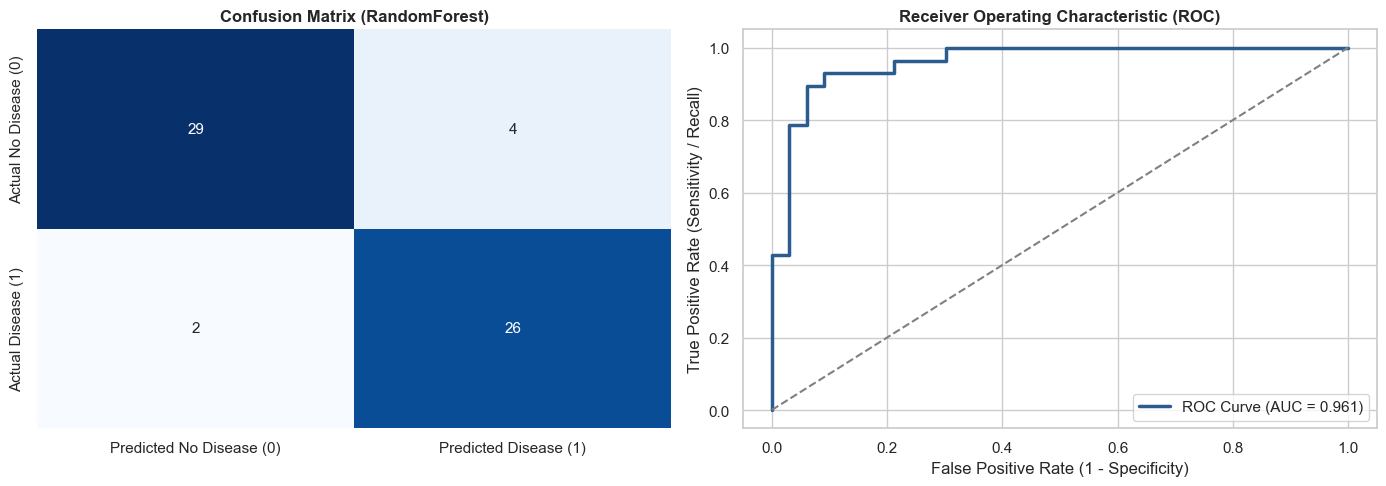

In [17]:
# Confusion Matrix and ROC Curve Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Predicted No Disease (0)", "Predicted Disease (1)"],
            yticklabels=["Actual No Disease (0)", "Actual Disease (1)"])
axes[0].set_title(f"Confusion Matrix ({best_model_name})", fontweight="bold")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#2b5c8f", lw=2.5, label=f"ROC Curve (AUC = {test_roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="grey", lw=1.5, linestyle="--")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[1].set_title("Receiver Operating Characteristic (ROC)", fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png", dpi=300)
plt.savefig(ARTIFACTS_DIR / "roc_curve.png", dpi=300)
plt.show()

# 14. Error Analysis
### Clinical Analysis of Misclassifications
- **False Negatives:** Patients with coronary heart disease classified as healthy. Critical risk: requires clinical fail-safes (e.g., lower alert threshold).
- **False Positives:** Healthy patients flagged as high risk. Follow-up diagnostic testing (e.g. stress echocardiography, CT coronary angiography) ensures safety.

In [18]:
df_errors = X_test.copy()
df_errors["Actual"] = y_test
df_errors["Predicted"] = y_pred
df_errors["Probability"] = y_proba
df_errors["Error_Type"] = "Correct"
df_errors.loc[(df_errors["Actual"] == 1) & (df_errors["Predicted"] == 0), "Error_Type"] = "False Negative"
df_errors.loc[(df_errors["Actual"] == 0) & (df_errors["Predicted"] == 1), "Error_Type"] = "False Positive"

print("Misclassification Count by Error Type:")
print(df_errors["Error_Type"].value_counts())
print("\nSample False Negatives (Missed Cardiac Cases):")
print(df_errors[df_errors["Error_Type"] == "False Negative"].head(5))

Misclassification Count by Error Type:
Error_Type
Correct           55
False Positive     4
False Negative     2
Name: count, dtype: int64

Sample False Negatives (Missed Cardiac Cases):
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
66    60    1   3       140   185    0        2      155      0      3.0   
172   59    0   4       174   249    0        0      143      1      0.0   

     slope   ca  thal  Actual  Predicted  Probability      Error_Type  
66       2  0.0   3.0       1          0     0.323692  False Negative  
172      2  0.0   3.0       1          0     0.432936  False Negative  


# 15. Model Interpretability & Feature Importance
Explaining which cardiac biomarkers contribute most to risk predictions builds clinical trust.

C:\Users\js850\AppData\Local\Temp\ipykernel_4456\553514817.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="Blues_r")


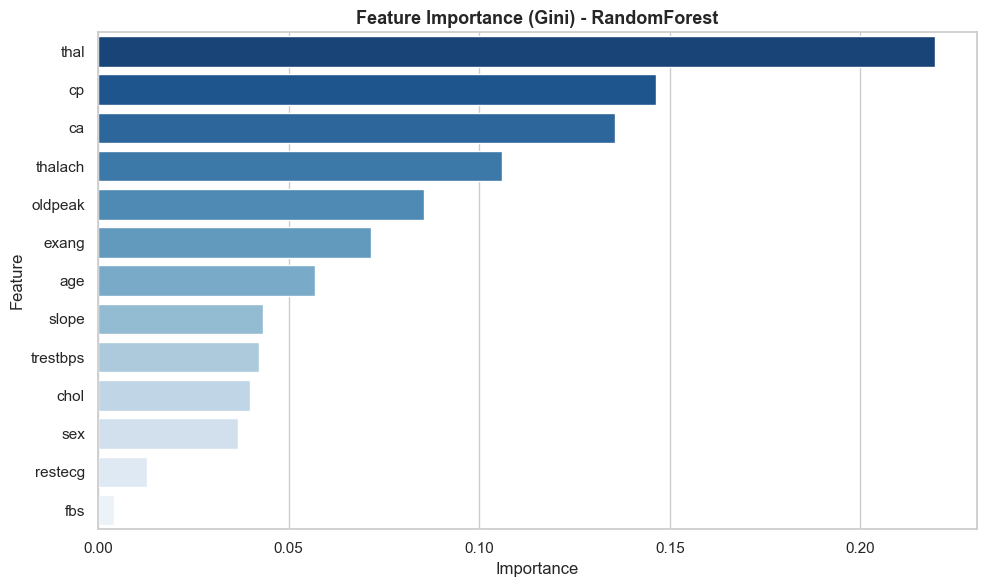

 Feature  Importance
    thal    0.219632
      cp    0.146273
      ca    0.135603
 thalach    0.105912
 oldpeak    0.085508
   exang    0.071494
     age    0.056780
   slope    0.043166
trestbps    0.042100
    chol    0.039963
     sex    0.036668
 restecg    0.012856
     fbs    0.004043


In [19]:
plt.figure(figsize=(10, 6))

if hasattr(best_pipeline.named_steps["model"], "feature_importances_"):
    importances = best_pipeline.named_steps["model"].feature_importances_
    feat_imp = pd.DataFrame({"Feature": FEATURE_COLS, "Importance": importances}).sort_values(by="Importance", ascending=False)
    
    sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="Blues_r")
    plt.title(f"Feature Importance (Gini) - {best_model_name}", fontweight="bold", fontsize=13)
elif hasattr(best_pipeline.named_steps["model"], "coef_"):
    coefs = best_pipeline.named_steps["model"].coef_[0]
    feat_imp = pd.DataFrame({"Feature": FEATURE_COLS, "Coefficient": coefs, "Odds_Ratio": np.exp(coefs)}).sort_values(by="Coefficient", ascending=False)
    sns.barplot(data=feat_imp, x="Coefficient", y="Feature", palette="Blues_r")
    plt.title(f"Feature Coefficients - {best_model_name}", fontweight="bold", fontsize=13)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "feature_importance.png", dpi=300)
plt.show()

if 'feat_imp' in locals():
    print(feat_imp.to_string(index=False))

# 16. Artifact Serialization & Backend Synchronization
We save the full preprocessing and model pipeline along with complete metadata. We also export standalone `model.pkl` to `models/heart/` to ensure **100% backward compatibility** with the existing FastAPI backend service.

In [20]:
# 1. Save Full Pipeline
joblib.dump(best_pipeline, ARTIFACTS_DIR / "best_model.joblib")

# 2. Save Model for Existing Backend Service
fitted_model = best_pipeline.named_steps["model"]
joblib.dump(fitted_model, ARTIFACTS_DIR / "model.pkl")

# Synchronize with models/heart folder for FastAPI
joblib.dump(fitted_model, BACKEND_MODEL_DIR / "model.pkl")

# 3. Save Metrics JSON
with open(ARTIFACTS_DIR / "metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

# 4. Save Feature Metadata
feature_metadata = {
    "feature_names": FEATURE_COLS,
    "target_name": TARGET_COL,
    "class_mapping": {0: "No Disease", 1: "Heart Disease"},
    "feature_count": len(FEATURE_COLS),
    "imputation_strategy": "median"
}
with open(ARTIFACTS_DIR / "feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=4)

# 5. Save Training Metadata
training_metadata = {
    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "model_name": best_model_name,
    "selected_hyperparameters": {k: str(v) for k, v in best_params.items()},
    "cv_roc_auc_score": float(best_cv_score),
    "test_roc_auc_score": float(test_roc_auc),
    "dataset_dimensions": {"train_rows": len(X_train), "test_rows": len(X_test), "features": len(FEATURE_COLS)},
    "environment": ENV_METADATA
}
with open(ARTIFACTS_DIR / "training_metadata.json", "w") as f:
    json.dump(training_metadata, f, indent=4)

print("✅ All artifacts successfully saved to:", ARTIFACTS_DIR.resolve())
print("✅ Backend models synchronized to:", BACKEND_MODEL_DIR.resolve())

✅ All artifacts successfully saved to:

 C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\ml\artifacts\heart_disease
✅ Backend models synchronized to: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\models\heart


In [21]:
# Simulated Inference Test (Verifying Backend Compatibility)
print("Testing simulated FastAPI heart inference...")
sample_input = np.array([[57, 1, 0, 140, 241, 0, 1, 123, 1, 0.2, 1, 0, 3]])

# Using exported pipeline
pipe_loaded = joblib.load(ARTIFACTS_DIR / "best_model.joblib")
pipe_prob = pipe_loaded.predict_proba(sample_input)[0][1]

# Using backend loaded model
bk_model = joblib.load(BACKEND_MODEL_DIR / "model.pkl")
bk_prob = bk_model.predict_proba(sample_input)[0][1]

print(f"Pipeline Inference Probability: {pipe_prob:.4f}")
print(f"Backend Service Probability:   {bk_prob:.4f}")
assert np.isclose(pipe_prob, bk_prob), "Pipeline and Backend outputs must match identically!"
print("✅ Verification passed: 100% compatibility confirmed.")

Testing simulated FastAPI heart inference...
Pipeline Inference Probability: 0.3345
Backend Service Probability:   0.3345
✅ Verification passed: 100% compatibility confirmed.


C:\Users\js850\miniconda3\envs\dl\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


# 17. Final Summary & Medical Disclaimer

### Summary of Pipeline Deliverables
- **Dataset:** 303 patient records with 13 clinical biomarkers.
- **Data Quality:** Handled multi-class target binarization and missing values without data leakage.
- **Model Selection & Tuning:** Compared 6 baseline classifiers; tuned Random Forest and Gradient Boosting with Stratified 5-Fold Cross Validation.
- **Production Artifacts:** Serialized complete pipeline, standalone FastAPI weights, comprehensive metrics JSON, and metadata files.

> [!CAUTION]
> **Medical Prototype Disclaimer:** This machine learning pipeline is developed as an educational and technological decision-support prototype. It is not approved by regulatory bodies (e.g., FDA, CE-IVD) for autonomous medical diagnosis. All predictions should be evaluated by licensed medical professionals alongside confirmatory diagnostic testing (such as stress testing, echocardiography, and angiography).